In [1]:
# Make video frame and mask overlay in two separate rows 

# need to be probed 

In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import cv2
from scipy import stats
from scipy.ndimage import zoom

# Configuration
GESTALT_BASE_PATH = '/home/esli/GenParticles_neural_stimulus/assets/from_thomas'
SEGANYMO_BASE_PATH = '/home/esli/SegAnyMo/gestalt_SegAnyMo_outputs'
HDGMM_BASE_PATH = '/home/esli/GenParticles_neural_stimulus/video_gestalt_masks'
OUTPUT_DIR = '/home/esli/GenParticles_neural_stimulus/analysis_results'

# Helper functions to load masks
def load_ground_truth_mask(scene, frame_idx):
    """Load ground truth binary mask (1000×1000)"""
    mask_file = os.path.join(GESTALT_BASE_PATH, scene, 'render_passes', 'masks', f'Image{frame_idx+1:04d}.png')
    if not os.path.exists(mask_file):
        return None
    mask_img = np.array(Image.open(mask_file))
    if mask_img.ndim == 3:
        mask_img = mask_img[:, :, 0]
    return mask_img > 127

def load_seganymo_mask(scene, texture, frame_idx):
    """Load SegAnyMo mask (1000×1000)
    
    SegAnyMo masks are typically grayscale images. For probabilistic segmentation,
    we need to treat them as having distinct segments. If the mask has many unique
    grayscale values, we should threshold it to create a binary mask (object vs background)
    or cluster similar values together.
    """
    mask_file = os.path.join(SEGANYMO_BASE_PATH, f'{scene}_{texture}', 'sam2', 'initial_preds', 
                              'output_six_frame', f'{frame_idx:05d}.png')
    if not os.path.exists(mask_file):
        return None
    mask_img = np.array(Image.open(mask_file))
    mask = mask_img[:, :, 0] if mask_img.ndim == 3 else mask_img
    
    # For probabilistic segmentation, we need segment IDs
    # SegAnyMo masks are typically binary (0 = background, non-zero = object)
    # or have a few distinct segments. If there are many unique values,
    # we should threshold to create a binary mask.
    unique_vals = np.unique(mask)
    
    if len(unique_vals) <= 2:
        # Binary mask - convert to 0/1 segment IDs
        mask = (mask > 0).astype(int)
    elif len(unique_vals) <= 20:
        # Few segments - map each unique value to a segment ID
        segment_map = {val: idx for idx, val in enumerate(unique_vals)}
        mask_mapped = np.zeros_like(mask, dtype=int)
        for val, seg_id in segment_map.items():
            mask_mapped[mask == val] = seg_id
        mask = mask_mapped
    else:
        # Many unique values (likely grayscale) - threshold to binary
        # Use median as threshold to separate object from background
        threshold = np.median(unique_vals)
        mask = (mask > threshold).astype(int)
    
    return mask

def load_flowsam_mask(scene, texture, frame_idx):
    """Load FlowSAM mask (1000×1000), colored by detected objects"""
    # Try flowsam directory first (has different masks per frame)
    mask_file = os.path.join(GESTALT_BASE_PATH, scene, texture, 'masks', 'flowsam', 
                              f'frame_{frame_idx:04d}_segmentation_indexed.png')
    if not os.path.exists(mask_file):
        # Fallback to flowsam_matched_reprocessed
        mask_file = os.path.join(GESTALT_BASE_PATH, scene, texture, 'masks', 'flowsam_matched_reprocessed', 
                                  f'frame_{frame_idx:05d}_matched.png')
        if not os.path.exists(mask_file):
            return None
    mask_img = np.array(Image.open(mask_file))
    return mask_img[:, :, 0] if mask_img.ndim == 3 else mask_img

def load_hdgmm_mask_single_run(scene, texture, frame_idx, run_idx=0):
    """Load HDGMM mask from single run (96×96)"""
    path = os.path.join(HDGMM_BASE_PATH, scene, texture, f'run_{run_idx}', 'assignments.npz')
    if not os.path.exists(path):
        return None
    data = np.load(path, allow_pickle=True)
    if 'pixel_hyperblob_assignments' not in data or frame_idx >= len(data['pixel_hyperblob_assignments']):
        return None
    return data['pixel_hyperblob_assignments'][frame_idx].astype(np.int32)

def load_hdgmm_mask(scene, texture, frame_idx, num_runs=5):
    """Load HDGMM mask averaged across runs using mode (96×96)"""
    masks = [load_hdgmm_mask_single_run(scene, texture, frame_idx, i) for i in range(num_runs)]
    masks = [m for m in masks if m is not None]
    if len(masks) == 0:
        return None
    if len(masks) == 1:
        return masks[0]
    masks_stack = np.stack(masks, axis=0)
    mode_mask, _ = stats.mode(masks_stack, axis=0, keepdims=False)
    return mode_mask.astype(np.int32)

def load_video_frames(video_path):
    """Load video frames from MP4 file."""
    if not os.path.exists(video_path):
        print(f"Video file not found: {video_path}")
        return None
    
    cap = cv2.VideoCapture(video_path)
    frames = []
    
    while True:
        ret, frame = cap.read()
        if not ret:
            break
        # Convert BGR to RGB
        frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        frames.append(frame_rgb)
    
    cap.release()
    
    if len(frames) == 0:
        print(f"No frames loaded from {video_path}")
        return None
    
    return frames

def create_probabilistic_segmentation_from_probes(true_mask, predicted_mask, num_probes=100, random_seed=None):
    """
    Create probabilistic segmentation by averaging binary segmentations from probe points.
    
    Methodology:
    1. Sample probe points from ground truth object region
    2. For each probe, get the segment ID it belongs to in predicted mask
    3. Create binary mask for that segment
    4. Average all binary masks to get probabilistic segmentation (0-1 values)
    
    Args:
        true_mask: Ground truth binary mask (H, W)
        predicted_mask: Predicted segmentation mask (H, W) with segment IDs
        num_probes: Number of probe points to sample
        random_seed: Random seed for reproducibility
    
    Returns:
        probabilistic_mask: Float array (H, W) with values in [0, 1] representing
                           probability that pixel belongs to object
        probe_locations: List of (y, x) coordinates of probe points
    """
    if true_mask is None or predicted_mask is None:
        return None, []
    
    # Resize predicted mask to match true mask if needed
    if true_mask.shape != predicted_mask.shape:
        zoom_factors = (true_mask.shape[0] / predicted_mask.shape[0], 
                       true_mask.shape[1] / predicted_mask.shape[1])
        predicted_mask = zoom(predicted_mask.astype(float), zoom_factors, order=0).astype(int)
    
    # Flatten masks
    h, w = true_mask.shape
    true_flat = true_mask.flatten()
    pred_flat = predicted_mask.flatten()
    
    # Sample probe points from object region
    object_indices = np.where(true_flat)[0]
    if len(object_indices) == 0:
        return np.zeros_like(true_mask, dtype=np.float32), []
    
    # Set random seed BEFORE sampling
    if random_seed is not None:
        np.random.seed(int(random_seed))
    else:
        # If no seed provided, use current state
        pass
    
    num_samples = min(num_probes, len(object_indices))
    probe_indices = np.random.choice(object_indices, size=num_samples, replace=False)
    
    # Convert flat indices to (y, x) coordinates
    probe_locations = [(idx // w, idx % w) for idx in probe_indices]
    
    # Initialize accumulator for probabilistic mask
    prob_mask = np.zeros((h, w), dtype=np.float32)
    
    # For each probe point, create binary mask for its segment and accumulate
    for probe_idx in probe_indices:
        segment_id = pred_flat[probe_idx]
        # Create binary mask for this segment
        segment_mask = (pred_flat == segment_id).reshape(h, w)
        # Accumulate (will average later)
        prob_mask = prob_mask + segment_mask.astype(np.float32)
    
    # Average to get probabilistic mask
    if num_samples > 0:
        prob_mask = prob_mask / num_samples
    
    return prob_mask, probe_locations

def overlay_mask_on_frame(frame, mask, alpha=0.5, cmap='tab20', is_probabilistic=False, prob_range=None):
    """Overlay a mask on a video frame.
    
    Args:
        frame: Video frame (H, W, 3)
        mask: Mask to overlay (H, W) - can be binary, integer segment IDs, or probabilistic [0, 1]
        alpha: Transparency of overlay
        cmap: Colormap to use
        is_probabilistic: If True, mask is already probabilistic [0, 1]. If False, will normalize.
        prob_range: Tuple (min, max) for standardizing probabilistic masks across all plots.
                   If None, will use mask's own min/max.
    """
    if mask is None:
        return frame
    
    # Resize mask to match frame dimensions if needed
    if mask.shape[:2] != frame.shape[:2]:
        zoom_factors = (frame.shape[0] / mask.shape[0], frame.shape[1] / mask.shape[1])
        mask_resized = zoom(mask.astype(float), zoom_factors, order=1 if is_probabilistic else 0)
    else:
        mask_resized = mask
    
    # Normalize mask to 0-1 range for colormap
    if is_probabilistic:
        # Probabilistic mask - use global range for standardization if provided
        if prob_range is not None:
            prob_min, prob_max = prob_range
            # Clip to global range and normalize to [0, 1]
            mask_clipped = np.clip(mask_resized, prob_min, prob_max)
            if prob_max > prob_min:
                mask_normalized = (mask_clipped - prob_min) / (prob_max - prob_min + 1e-8)
            else:
                mask_normalized = np.zeros_like(mask_clipped, dtype=np.float32)
        else:
            # Fallback: use mask's own range
            mask_min = mask_resized.min()
            mask_max = mask_resized.max()
            if mask_max > mask_min:
                mask_normalized = (mask_resized - mask_min) / (mask_max - mask_min + 1e-8)
            else:
                mask_normalized = np.clip(mask_resized.astype(np.float32), 0.0, 1.0)
    else:
        # Not probabilistic - normalize based on type
        if mask_resized.dtype != np.float32:
            mask_resized = mask_resized.astype(np.float32)
        
        unique_vals = np.unique(mask_resized)
        if len(unique_vals) == 1:
            # Single value mask - use binary overlay
            mask_normalized = (mask_resized > 0).astype(np.float32)
        else:
            # Multi-value mask - normalize to 0-1
            mask_normalized = (mask_resized - mask_resized.min()) / (mask_resized.max() - mask_resized.min() + 1e-8)
    
    # Apply colormap
    cmap_obj = plt.get_cmap(cmap)
    mask_colored = cmap_obj(mask_normalized)[:, :, :3]  # Remove alpha channel
    mask_colored = (mask_colored * 255).astype(np.uint8)
    
    # Overlay mask on frame
    overlay = (1 - alpha) * frame + alpha * mask_colored
    return overlay.astype(np.uint8)

Loaded 6 frames from video

Loading masks for frame 0:
  Ground Truth: ✓
  SegAnyMo: ✓
  FlowSAM: ✓
  GenMatter (HDGMM): ✓
  Probe point: (461, 603)

Loading masks for frame 4:
  Ground Truth: ✓
  SegAnyMo: ✓
  FlowSAM: ✓
  GenMatter (HDGMM): ✓
  Probe point: (667, 465)

Segmentation Comparison: scene_00016 - texture_07

Figure saved to: /home/esli/GenParticles_neural_stimulus/analysis_results/paper_figure_comparison_scene_00016_texture_07_frames0_4.pdf


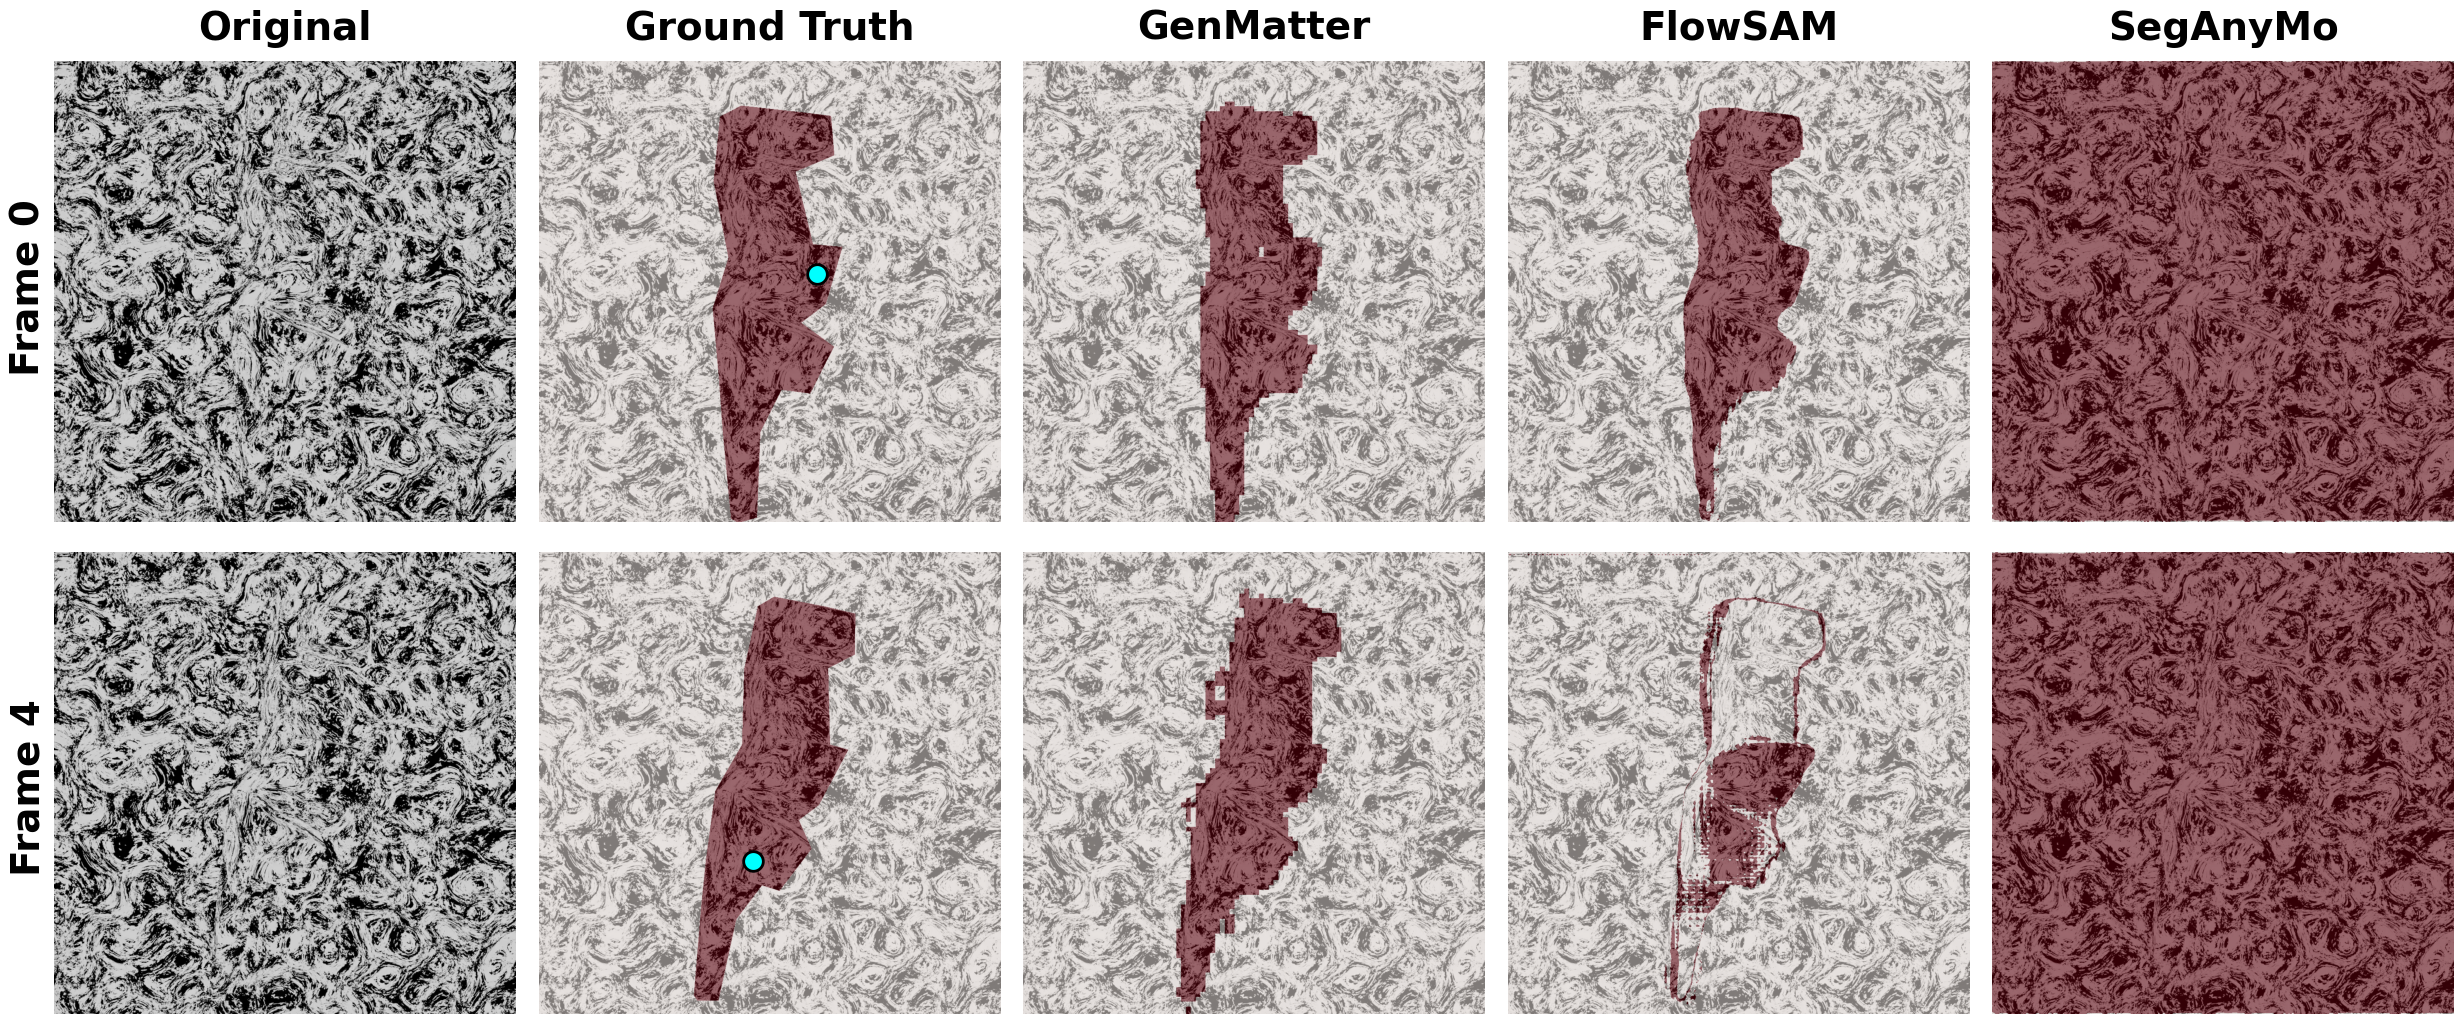

In [3]:
# Create visualization figure showing segmentation overlays based on a single probe point
# Layout: 2 rows x 5 columns
# Row 1: Frame 0 - [Original] [Ground Truth with probe] [GenMatter segment] [FlowSAM segment] [SegAnyMo segment]
# Row 2: Frame 4 - [Original] [Ground Truth with probe] [GenMatter segment] [FlowSAM segment] [SegAnyMo segment]

def get_segment_from_probe(mask, probe_y, probe_x):
    """Get the binary mask for the segment containing the probe point."""
    if mask is None:
        return None
    h, w = mask.shape
    if probe_y < 0 or probe_y >= h or probe_x < 0 or probe_x >= w:
        return None
    segment_id = mask[probe_y, probe_x]
    return (mask == segment_id).astype(float)

def sample_probe_point(true_mask, random_seed=None):
    """Sample a single probe point from the ground truth object region."""
    if true_mask is None:
        return None, None
    
    # Flatten mask
    h, w = true_mask.shape
    true_flat = true_mask.flatten()
    
    # Get object region indices
    object_indices = np.where(true_flat)[0]
    if len(object_indices) == 0:
        return None, None
    
    # Set random seed
    if random_seed is not None:
        np.random.seed(int(random_seed))
    
    # Sample single probe point
    probe_idx = np.random.choice(object_indices)
    probe_y = probe_idx // w
    probe_x = probe_idx % w
    
    return probe_y, probe_x

scene = 'scene_00016'
texture = 'texture_07'
frame_indices = [0, 4]  # Frames to display

# Load video frames
video_path = os.path.join(GESTALT_BASE_PATH, scene, texture, 'output_six_frame.mp4')
frames = load_video_frames(video_path)

if frames is None:
    print(f"Could not load video frames from {video_path}")
else:
    print(f"Loaded {len(frames)} frames from video")
    
    # Create figure: 2 rows x 5 columns (Original, GT, GenMatter, FlowSAM, SegAnyMo)
    fig, axes = plt.subplots(2, 5, figsize=(25, 10))
    
    for row_idx, frame_idx in enumerate(frame_indices):
        if frame_idx >= len(frames):
            print(f"Frame {frame_idx} not available (only {len(frames)} frames)")
            continue
            
        frame = frames[frame_idx]
        
        # Load all masks for this frame
        print(f"\nLoading masks for frame {frame_idx}:")
        
        # Ground Truth: frame_idx+1 (1-indexed)
        gt_mask = load_ground_truth_mask(scene, frame_idx)
        print(f"  Ground Truth: {'✓' if gt_mask is not None else '✗'}")
        
        # SegAnyMo: frame_idx (0-indexed)
        seganymo_mask = load_seganymo_mask(scene, texture, frame_idx)
        print(f"  SegAnyMo: {'✓' if seganymo_mask is not None else '✗'}")
        
        # FlowSAM: frame_idx (0-indexed, but uses 4-digit format in flowsam directory)
        flowsam_mask = load_flowsam_mask(scene, texture, frame_idx)
        print(f"  FlowSAM: {'✓' if flowsam_mask is not None else '✗'}")
        
        # HDGMM/GenMatter: frame_idx (0-indexed)
        hdgmm_mask = load_hdgmm_mask(scene, texture, frame_idx)
        print(f"  GenMatter (HDGMM): {'✓' if hdgmm_mask is not None else '✗'}")
        
        # Resize all masks to match frame dimensions
        if gt_mask is not None and gt_mask.shape[:2] != frame.shape[:2]:
            zoom_factors = (frame.shape[0] / gt_mask.shape[0], frame.shape[1] / gt_mask.shape[1])
            gt_mask_resized = zoom(gt_mask.astype(float), zoom_factors, order=0) > 0.5
        else:
            gt_mask_resized = gt_mask
        
        if seganymo_mask is not None and seganymo_mask.shape[:2] != frame.shape[:2]:
            zoom_factors = (frame.shape[0] / seganymo_mask.shape[0], frame.shape[1] / seganymo_mask.shape[1])
            seganymo_mask_resized = zoom(seganymo_mask.astype(float), zoom_factors, order=0).astype(int)
        else:
            seganymo_mask_resized = seganymo_mask
        
        if flowsam_mask is not None and flowsam_mask.shape[:2] != frame.shape[:2]:
            zoom_factors = (frame.shape[0] / flowsam_mask.shape[0], frame.shape[1] / flowsam_mask.shape[1])
            flowsam_mask_resized = zoom(flowsam_mask.astype(float), zoom_factors, order=0).astype(int)
        else:
            flowsam_mask_resized = flowsam_mask
        
        if hdgmm_mask is not None and hdgmm_mask.shape[:2] != frame.shape[:2]:
            zoom_factors = (frame.shape[0] / hdgmm_mask.shape[0], frame.shape[1] / hdgmm_mask.shape[1])
            hdgmm_mask_resized = zoom(hdgmm_mask.astype(float), zoom_factors, order=0).astype(int)
        else:
            hdgmm_mask_resized = hdgmm_mask
        
        # Sample a single probe point from ground truth object region
        # Use deterministic seed based on scene, texture, and frame for reproducibility
        scene_num = int(scene.split('_')[1])
        texture_num = int(texture.split('_')[1])
        probe_seed = 42 + scene_num * 1000 + texture_num * 10 + frame_idx
        
        probe_y, probe_x = sample_probe_point(gt_mask_resized, random_seed=probe_seed)
        print(f"  Probe point: ({probe_y}, {probe_x})")
        
        # Get segments containing the probe point for each method
        hdgmm_segment = get_segment_from_probe(hdgmm_mask_resized, probe_y, probe_x)
        flowsam_segment = get_segment_from_probe(flowsam_mask_resized, probe_y, probe_x)
        seganymo_segment = get_segment_from_probe(seganymo_mask_resized, probe_y, probe_x)
        
        # Column 0: Original frame
        axes[row_idx, 0].imshow(frame)
        if row_idx == 0:
            axes[row_idx, 0].set_title('Original', fontsize=28, fontweight='bold', pad=15)
        axes[row_idx, 0].axis('off')
        
        # Column 1: Ground Truth with probe point marked
        gt_overlay = overlay_mask_on_frame(frame, gt_mask_resized, alpha=0.5, cmap='Reds', 
                                           is_probabilistic=False, prob_range=None)
        axes[row_idx, 1].imshow(gt_overlay)
        # Mark probe point on ground truth
        if probe_y is not None and probe_x is not None:
            axes[row_idx, 1].scatter([probe_x], [probe_y], c='cyan', s=200, 
                                    edgecolors='black', linewidths=2, alpha=1.0, zorder=10,
                                    marker='o')
        if row_idx == 0:
            axes[row_idx, 1].set_title('Ground Truth', fontsize=28, fontweight='bold', pad=15)
        axes[row_idx, 1].axis('off')
        
        # Column 2: GenMatter segment containing probe point
        if hdgmm_segment is not None:
            hdgmm_overlay = overlay_mask_on_frame(frame, hdgmm_segment, alpha=0.5, cmap='Reds', 
                                                  is_probabilistic=False, prob_range=None)
            axes[row_idx, 2].imshow(hdgmm_overlay)
        else:
            axes[row_idx, 2].imshow(frame)
        if row_idx == 0:
            axes[row_idx, 2].set_title('GenMatter', fontsize=28, fontweight='bold', pad=15)
        axes[row_idx, 2].axis('off')
        
        # Column 3: FlowSAM segment containing probe point
        if flowsam_segment is not None:
            flowsam_overlay = overlay_mask_on_frame(frame, flowsam_segment, alpha=0.5, cmap='Reds', 
                                                    is_probabilistic=False, prob_range=None)
            axes[row_idx, 3].imshow(flowsam_overlay)
        else:
            axes[row_idx, 3].imshow(frame)
        if row_idx == 0:
            axes[row_idx, 3].set_title('FlowSAM', fontsize=28, fontweight='bold', pad=15)
        axes[row_idx, 3].axis('off')
        
        # Column 4: SegAnyMo segment containing probe point
        if seganymo_segment is not None:
            seganymo_overlay = overlay_mask_on_frame(frame, seganymo_segment, alpha=0.5, cmap='Reds', 
                                                     is_probabilistic=False, prob_range=None)
            axes[row_idx, 4].imshow(seganymo_overlay)
        else:
            axes[row_idx, 4].imshow(frame)
        if row_idx == 0:
            axes[row_idx, 4].set_title('SegAnyMo', fontsize=28, fontweight='bold', pad=15)
        axes[row_idx, 4].axis('off')
        
        # Add row label on the left (significantly larger font)
        fig.text(0.01, 0.75 - row_idx * 0.5, f'Frame {frame_idx}', 
             fontsize=28, fontweight='bold', rotation=90, va='center', ha='center')
    
    # Print title to console instead of including in figure
    plot_title = f'Segmentation Comparison: {scene} - {texture}'
    print(f"\n{plot_title}")
    
    # Use subplots_adjust to position subplots
    # Tighten row spacing to match column spacing (wspace = hspace)
    plt.subplots_adjust(left=0.02, right=0.98, top=0.98, bottom=0.02, wspace=0.05, hspace=0.05)
    
    # Save figure as PDF
    output_path = os.path.join(OUTPUT_DIR, f'paper_figure_comparison_{scene}_{texture}_frames{frame_indices[0]}_{frame_indices[1]}.pdf')
    os.makedirs(OUTPUT_DIR, exist_ok=True)
    plt.savefig(output_path, format='pdf', bbox_inches='tight')
    print(f"\nFigure saved to: {output_path}")
    
    plt.show()


Loaded 6 frames from video
Frame 0: SegAnyMo has 1 segments (IDs: [1])
Frame 4: SegAnyMo has 1 segments (IDs: [1])



Figure saved to: /home/esli/GenParticles_neural_stimulus/analysis_results/seganymo_inferred_masks_scene_00016_texture_07_frames0_4.png


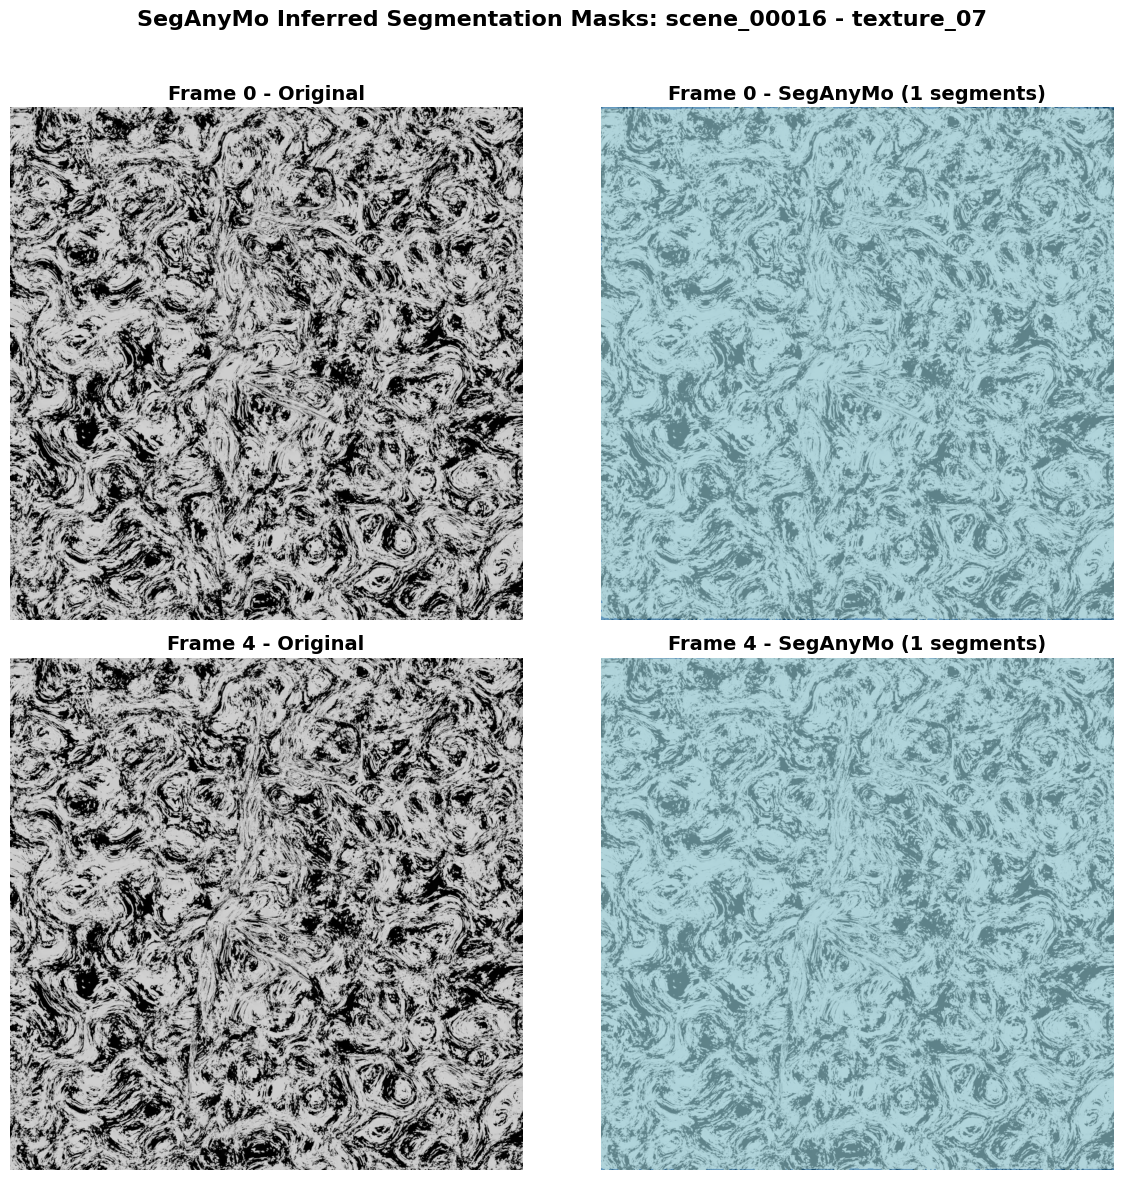

In [4]:
# Show SegAnyMo inferred segmentation masks separately
# This displays the raw SegAnyMo masks with their segment IDs

frame_indices = [0, 4]  # Frames to display

# Load video frames
video_path = os.path.join(GESTALT_BASE_PATH, scene, texture, 'output_six_frame.mp4')
frames = load_video_frames(video_path)

if frames is None:
    print(f"Could not load video frames from {video_path}")
else:
    print(f"Loaded {len(frames)} frames from video")
    
    # Create figure: 2 rows x 2 columns (original frame + SegAnyMo mask for each frame)
    fig, axes = plt.subplots(2, 2, figsize=(12, 12))
    
    for row_idx, frame_idx in enumerate(frame_indices):
        if frame_idx >= len(frames):
            print(f"Frame {frame_idx} not available (only {len(frames)} frames)")
            continue
            
        frame = frames[frame_idx]
        
        # Load SegAnyMo mask (raw, with segment IDs)
        seganymo_mask = load_seganymo_mask(scene, texture, frame_idx)
        
        if seganymo_mask is None:
            print(f"  SegAnyMo mask not available for frame {frame_idx}")
            continue
        
        # Left column: Original frame
        axes[row_idx, 0].imshow(frame)
        axes[row_idx, 0].set_title(f'Frame {frame_idx} - Original', fontsize=14, fontweight='bold')
        axes[row_idx, 0].axis('off')
        
        # Right column: SegAnyMo inferred segmentation mask
        # Resize mask to match frame dimensions
        if seganymo_mask.shape[:2] != frame.shape[:2]:
            zoom_factors = (frame.shape[0] / seganymo_mask.shape[0], frame.shape[1] / seganymo_mask.shape[1])
            seganymo_resized = zoom(seganymo_mask.astype(float), zoom_factors, order=0).astype(int)
        else:
            seganymo_resized = seganymo_mask
        
        # Show SegAnyMo mask with segment IDs using tab20 colormap (good for discrete segments)
        overlay = overlay_mask_on_frame(frame, seganymo_resized, alpha=0.6, cmap='tab20', is_probabilistic=False)
        axes[row_idx, 1].imshow(overlay)
        
        # Get unique segments for display
        unique_segments = np.unique(seganymo_resized)
        num_segments = len(unique_segments[unique_segments > 0])  # Exclude background (0)
        axes[row_idx, 1].set_title(f'Frame {frame_idx} - SegAnyMo ({num_segments} segments)', 
                                   fontsize=14, fontweight='bold')
        axes[row_idx, 1].axis('off')
        
        print(f"Frame {frame_idx}: SegAnyMo has {num_segments} segments (IDs: {unique_segments[unique_segments > 0]})")
    
    plt.suptitle(f'SegAnyMo Inferred Segmentation Masks: {scene} - {texture}', 
                 fontsize=16, fontweight='bold', y=0.98)
    
    plt.tight_layout(rect=[0, 0, 1, 0.96])  # Leave space for title
    
    # Save figure
    output_path = os.path.join(OUTPUT_DIR, f'seganymo_inferred_masks_{scene}_{texture}_frames{frame_indices[0]}_{frame_indices[1]}.png')
    os.makedirs(OUTPUT_DIR, exist_ok=True)
    plt.savefig(output_path, dpi=300, bbox_inches='tight')
    print(f"\nFigure saved to: {output_path}")
    
    plt.show()
